### Setting up the Environment for LSTM Model

First, we'll import the necessary libraries. We'll use TensorFlow/Keras for building the LSTM model, pandas for data manipulation, and scikit-learn for preprocessing.

In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from keras.preprocessing.sequence import pad_sequences

### Data Loading and Initial Inspection

You'll need to load your data into a pandas DataFrame. Assuming your data is in a CSV file, you can use `pd.read_csv()`. Make sure your dataset contains columns for FSR, accelerometer (e.g., `accel_x`, `accel_y`, `accel_z`), gyroscope (e.g., `gyro_x`, `gyro_y`, `gyro_z`), and the 'runner type' target.

Replace `'your_data.csv'` with the actual path to your dataset.

In [3]:
# Load your dataset
# Example: df = pd.read_csv('your_data.csv')
# For demonstration, let's create a dummy DataFrame
data = {
    'fsr': np.random.randint(0, 100, 1000), # Unidirectional integer
    'accel_x': np.random.rand(1000) * 9.8, 'accel_y': np.random.rand(1000) * 9.8, 'accel_z': np.random.rand(1000) * 9.8,
    'gyro_x': np.random.rand(1000) * 200, 'gyro_y': np.random.rand(1000) * 200, 'gyro_z': np.random.rand(1000) * 200,
    'runner_type': np.random.choice(['sprinter', 'distance', 'jogger'], 1000)
}
df = pd.DataFrame(data)

display(df.head())
print(df.info())

,fsr,accel_x,accel_y,accel_z,gyro_x,gyro_y,gyro_z,runner_type
0,24,8.888508,1.273723,9.443015,50.458272,66.336641,86.043818,distance
1,28,1.372842,7.946838,1.708406,9.413076,21.423509,182.615113,sprinter
2,49,7.845743,0.820555,4.354541,20.352709,114.704349,24.957862,distance
3,97,1.519127,1.330531,5.694960,81.537791,22.765336,73.310266,distance
4,94,6.621039,9.199036,3.484543,0.517791,75.569743,72.199305,distance


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   fsr          1000 non-null   int32  
 1   accel_x      1000 non-null   float64
 2   accel_y      1000 non-null   float64
 3   accel_z      1000 non-null   float64
 4   gyro_x       1000 non-null   float64
 5   gyro_y       1000 non-null   float64
 6   gyro_z       1000 non-null   float64
 7   runner_type  1000 non-null   str    
dtypes: float64(6), int32(1), str(1)
memory usage: 58.7 KB
None


### Data Preprocessing for LSTM

LSTM models require data to be in a sequential format. This typically involves:
1.  **Feature Selection**: Identifying the columns that serve as features.
2.  **Scaling Numerical Features**: FSR, accelerometer, and gyroscope values should be scaled (e.g., using `MinMaxScaler`) to a range like `[0, 1]` or `[-1, 1]`.
3.  **Encoding Categorical Target**: The 'best kind of runner' (e.g., 'sprinter', 'distance', 'jogger') needs to be converted into numerical labels (e.g., using `LabelEncoder`).
4.  **Sequence Creation**: Transforming the flat data into sequences (e.g., using a sliding window approach) where each input sample to the LSTM is a sequence of observations over time.
5.  **Padding Sequences**: Ensuring all sequences have the same length, which is crucial for batch processing in LSTMs.

In [ ]:
# Define features and target
features = ['fsr', 'accel_x', 'accel_y', 'accel_z', 'gyro_x', 'gyro_y', 'gyro_z']
target = 'runner_type', 

# Scale numerical features
scaler = MinMaxScaler()
df[features] = scaler.fit_transform(df[features])

# Encode target variable
label_encoder = LabelEncoder()
target = 'runner_type'
df[target] = label_encoder.fit_transform(df[target])

# Display scaled features and encoded target
display(df.head())
print(f"Encoded runner types: {label_encoder.classes_}")

# --- Sequence Creation (Conceptual) ---
# This part highly depends on how your time-series data is structured.
# If your data is already sequential by rows and you want to create windows, you'd do something like this:

def create_sequences(data, time_steps):
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i:(i + time_steps), :-1])  # Features for 'time_steps'
        y.append(data[i + time_steps, -1])     # Target at 'time_steps' + 1 (or end of sequence)
    return np.array(X), np.array(y)

# Assuming 'df' is now all numerical (features and encoded target)
# combined_data = df[features + [target]].values
# time_steps = 10 # Example: use 10 previous readings to predict the next
# X_sequences, y_sequences = create_sequences(combined_data, time_steps)

# For simplicity here, let's just use the current row as a sequence of 1 (needs adjustment for actual sequences)
# In a real scenario, you would group data by user/session and then create sequences within those groups.

# Let's mock up sequence creation for the dummy data
def create_sliding_windows(data_df, feature_cols, target_col, window_size, step_size=1):
    X_seq, y_seq = [], []
    data_values = data_df[feature_cols].values
    target_values = data_df[target_col].values

    for i in range(0, len(data_values) - window_size, step_size):
        X_seq.append(data_values[i:i + window_size])
        # For classification, target could be the runner_type at the end of the window
        y_seq.append(target_values[i + window_size - 1])
    return np.array(X_seq), np.array(y_seq)

window_size = 5 # Example: each sequence will be 5 time steps long
X_seq, y_seq = create_sliding_windows(df, features, target, window_size)

print(f"Shape of X_sequences: {X_seq.shape}") # (num_samples, window_size, num_features)
print(f"Shape of y_sequences: {y_seq.shape}") # (num_samples,)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_seq, y_seq, test_size=0.2, random_state=42, stratify=y_seq)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

KeyError: ('runner_type',)

### Building the LSTM Model

Now, let's define the architecture of our LSTM model. We'll use Keras for this. The model will consist of an LSTM layer, followed by a Dropout layer (to prevent overfitting), and a Dense output layer with softmax activation for multi-class classification. The number of output units in the dense layer will correspond to the number of unique runner types.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical

# Determine the number of features and output classes
num_features = X_train.shape[2]
num_classes = len(label_encoder.classes_)

# Convert target to one-hot encoding for categorical cross-entropy
y_train_one_hot = to_categorical(y_train, num_classes=num_classes)
y_test_one_hot = to_categorical(y_test, num_classes=num_classes)

# Define the LSTM model
model = Sequential()
model.add(LSTM(units=50, activation='relu', input_shape=(window_size, num_features)))
model.add(Dropout(0.2))
model.add(Dense(units=num_classes, activation='softmax'))

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        11,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │           153 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,753 (45.91 KB)

 Trainable params: 11,753 (45.91 KB)

 Non-trainable params: 0 (0.00 B)

### Training the LSTM Model

We will now train the LSTM model using the prepared training data. We'll specify the number of epochs and batch size. A validation split is also used to monitor the model's performance on unseen data during training.

In [ ]:
history = model.fit(X_train, y_train_one_hot, epochs=50, batch_size=32, validation_split=0.2, verbose=1)

# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test, y_test_one_hot, verbose=0)
print(f"\nTest Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.3632 - loss: 1.0981 - val_accuracy: 0.3125 - val_loss: 1.1018
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3459 - loss: 1.0957 - val_accuracy: 0.2875 - val_loss: 1.1031
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3758 - loss: 1.0934 - val_accuracy: 0.3000 - val_loss: 1.1014
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3664 - loss: 1.0954 - val_accuracy: 0.3000 - val_loss: 1.1016
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3601 - loss: 1.0954 - val_accuracy: 0.3000 - val_loss: 1.1026
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3569 - loss: 1.0939 - val_accuracy: 0.3438 - val_loss: 1.1011
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3506 - loss: 1.0925 - val_accuracy: 0.2875 - val_loss: 1.1031
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4057 - loss: 1.0907 - val_accuracy: 0.3812 - val_

### Visualizing Training History

It's often helpful to visualize the training and validation loss and accuracy over epochs to understand model convergence and identify potential overfitting.

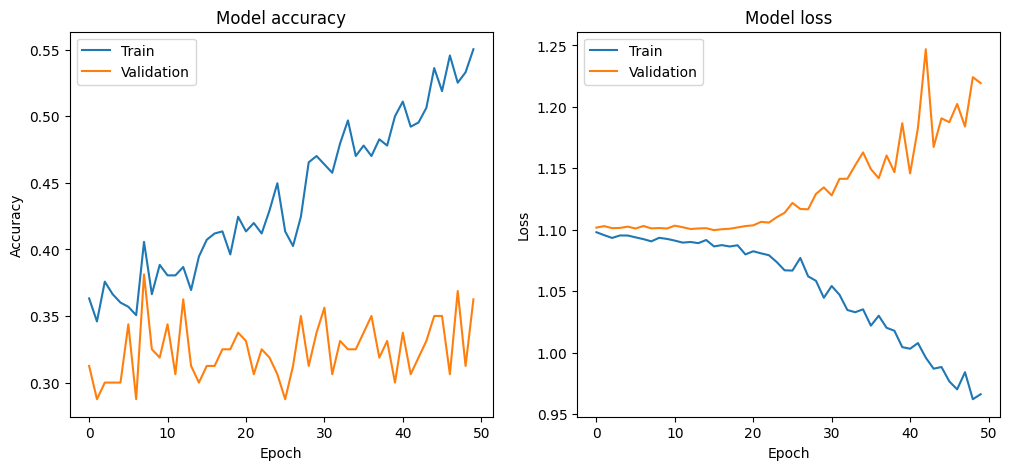

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

### Making Predictions and Interpreting Results

Finally, let's make some predictions on the test set and see how well our model classifies the runner types. We can also look at the classification report and confusion matrix for a more detailed evaluation.

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step

Classification Report:
              precision    recall  f1-score   support

    distance       0.32      0.46      0.38        68
      jogger       0.34      0.29      0.31        68
    sprinter       0.26      0.17      0.21        63

    accuracy                           0.31       199
   macro avg       0.30      0.31      0.30       199
weighted avg       0.31      0.31      0.30       199



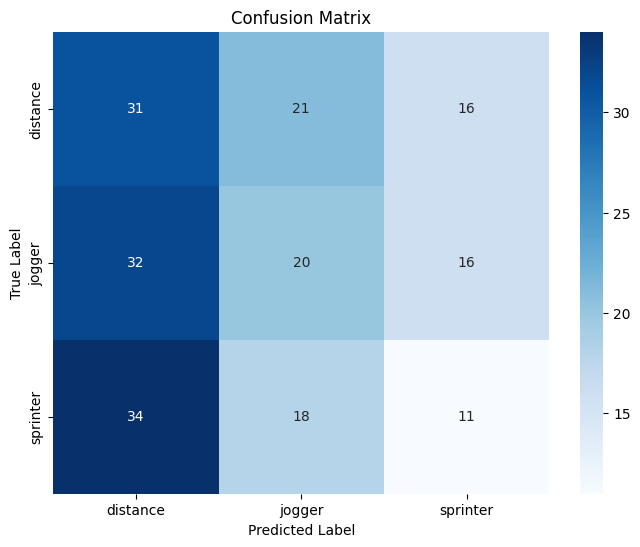

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Make predictions on the test set
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Decode numerical predictions back to original runner types
y_pred_labels = label_encoder.inverse_transform(y_pred)
y_test_labels = label_encoder.inverse_transform(np.argmax(y_test_one_hot, axis=1))

print("\nClassification Report:")
print(classification_report(y_test_labels, y_pred_labels))

# Confusion Matrix
cm = confusion_matrix(y_test_labels, y_pred_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Multi-Output Model: Classification & Regression

Here we will build a model that predicts **both** the runner type (categorical) and the running efficiency (continuous 1-100 score).

First, let's update our dummy data to include an `efficiency` column and modify our sequence generation to output two separate targets.

In [ ]:
# 1. Update Dummy Data with 'efficiency'
df_multi = df.copy()
df_multi['efficiency'] = np.random.uniform(1, 100, len(df_multi)) # Dummy efficiency 1-100

# 2. Update sequence creation for multiple targets
def create_multi_output_sequences(data_df, feature_cols, target_cat_col, target_cont_col, window_size, step_size=1):
    X_seq, y_cat_seq, y_cont_seq = [], [], []
    data_values = data_df[feature_cols].values
    target_cat_values = data_df[target_cat_col].values
    target_cont_values = data_df[target_cont_col].values

    for i in range(0, len(data_values) - window_size, step_size):
        X_seq.append(data_values[i:i + window_size])
        # Targets at the end of the window
        y_cat_seq.append(target_cat_values[i + window_size - 1])
        y_cont_seq.append(target_cont_values[i + window_size - 1])

    return np.array(X_seq), np.array(y_cat_seq), np.array(y_cont_seq)

# Generate sequences
X_multi, y_cat, y_cont = create_multi_output_sequences(df_multi, features, 'runner_type', 'efficiency', window_size)

# One-hot encode the categorical target
y_cat_one_hot = to_categorical(y_cat, num_classes=len(label_encoder.classes_))

# Split data (using the same random state to keep it aligned)
X_train_m, X_test_m, y_cat_train, y_cat_test, y_cont_train, y_cont_test = train_test_split(
    X_multi, y_cat_one_hot, y_cont, test_size=0.2, random_state=42
)

print(f"X_train shape: {X_train_m.shape}")
print(f"Categorical target shape: {y_cat_train.shape}")
print(f"Continuous target shape: {y_cont_train.shape}")

X_train shape: (796, 5, 7)
Categorical target shape: (796, 3)
Continuous target shape: (796,)


Now, we use the **Keras Functional API** to create branching outputs. The shared LSTM layer learns the time-series patterns, and then the network splits into two separate `Dense` heads: one for classification (Softmax) and one for regression (Linear).

In [ ]:
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.models import Model

# Input layer
inputs = Input(shape=(window_size, num_features), name='sensor_inputs')

# Shared LSTM representation
x = LSTM(units=64, activation='relu', return_sequences=False)(inputs)
x = Dropout(0.2)(x)

# Branch 1: Runner Type Classification (Categorical)
# Uses softmax for multi-class probability
runner_type_out = Dense(units=num_classes, activation='softmax', name='runner_type_output')(x)

# Branch 2: Efficiency Score (Regression)
# Uses linear activation (default) to predict a continuous number 1-100
efficiency_out = Dense(units=1, activation='linear', name='efficiency_output')(x)

# Define the model with multiple outputs
multi_model = Model(inputs=inputs, outputs=[runner_type_out, efficiency_out])

# Compile the model with two different loss functions
# categorical_crossentropy for classification, mean_squared_error for regression
multi_model.compile(
    optimizer='adam',
    loss={
        'runner_type_output': 'categorical_crossentropy',
        'efficiency_output': 'mse'
    },
    # We can also assign different weights to the losses if one task is more important
    loss_weights={
        'runner_type_output': 1.0,
        'efficiency_output': 0.01  # Scaled down so MSE doesn't dominate the gradient entirely
    },
    metrics={
        'runner_type_output': 'accuracy',
        'efficiency_output': 'mae' # Mean Absolute Error is easier to interpret (e.g. +/- 5% efficiency)
    }
)

multi_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sensor_inputs       │ (None, 5, 7)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 64)        │     18,432 │ sensor_inputs[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ runner_type_output  │ (None, 3)         │        195 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficiency_output   │ (None, 1)         │         65 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 18,692 (73.02 KB)

 Trainable params: 18,692 (73.02 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the multi-output model
# Notice we pass a dictionary for the targets to match the output layer names
history_multi = multi_model.fit(
    X_train_m,
    {
        'runner_type_output': y_cat_train,
        'efficiency_output': y_cont_train
    },
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Evaluate the model
eval_results = multi_model.evaluate(X_test_m, {'runner_type_output': y_cat_test, 'efficiency_output': y_cont_test}, verbose=0)
print(f"\nEvaluation Results (Overall Loss, Cat Loss, Cont Loss, Cat Acc, Cont MAE):\n{eval_results}")

Epoch 1/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step - efficiency_output_loss: 3392.7993 - efficiency_output_mae: 50.8443 - loss: 35.0596 - runner_type_output_accuracy: 0.3381 - runner_type_output_loss: 1.1061 - val_efficiency_output_loss: 3423.0657 - val_efficiency_output_mae: 51.2062 - val_loss: 35.3314 - val_runner_type_output_accuracy: 0.3500 - val_runner_type_output_loss: 1.1007
Epoch 2/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - efficiency_output_loss: 3112.5586 - efficiency_output_mae: 48.0629 - loss: 32.3612 - runner_type_output_accuracy: 0.3349 - runner_type_output_loss: 1.1828 - val_efficiency_output_loss: 2534.5698 - val_efficiency_output_mae: 42.4297 - val_loss: 26.4962 - val_runner_type_output_accuracy: 0.3500 - val_runner_type_output_loss: 1.1505
Epoch 3/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - efficiency_output_loss: 1361.4952 - efficiency_output_mae: 30.1137 - loss: 16.4487 - runner_type_output_accuracy: 0.3553 - runner_type_output_loss: 2.8193 - val_efficiency_outpu

### Next Steps: Integrating Real Data

Now that the multi-output LSTM pipeline is verified to work, it's time to swap out the dummy data.

When you collect your real data, ensure it is formatted as a CSV with columns matching our features (e.g., `fsr`, `accel_x`, `accel_y`, `accel_z`, `gyro_x`, `gyro_y`, `gyro_z`) and your ground truth labels (`runner_type`, `efficiency`).

Use the cell below to load and verify your real dataset once it is ready.

In [ ]:
# 1. Upload your CSV file to Colab (using the folder icon on the left panel)
# 2. Update the filename below
real_data_path = 'my_real_runner_data.csv'

try:
    # Load the real dataset
    real_df = pd.read_csv(real_data_path)

    print("Real data loaded successfully!")
    display(real_df.head())

    # Basic sanity checks
    print("\n--- Data Info ---")
    print(real_df.info())

    print("\n--- Missing Values ---")
    print(real_df.isnull().sum())

    # If this succeeds, you can go back up to the 'Data Preprocessing for LSTM' section,
    # replace 'df' with 'real_df', and re-run the pipeline!
    # df = real_df.copy()

except FileNotFoundError:
    print(f"File '{real_data_path}' not found. Please upload it to the Colab environment.")


File 'my_real_runner_data.csv' not found. Please upload it to the Colab environment.


### Ground Truth Labeling: Biomechanical Efficiency Score

There is no single universal formula for biomechanical efficiency without a metabolic cart, but sports scientists commonly use a composite score of wasted mechanical work.

The formula below calculates a **1-100 efficiency score** for a window of time (e.g., one stride or one second of running) by penalizing inefficient movements:

*   **FSR (Ground Contact Time):** High contact time = heavy steps (penalty).
*   **Accel Z (Vertical Oscillation):** High variance in the vertical axis = bouncing (penalty).
*   **Accel Y/X (Braking):** High deceleration peaks = braking against forward momentum (penalty).

In [ ]:
def calculate_efficiency_score(window_df, fsr_col='fsr', vertical_accel_col='accel_z', forward_accel_col='accel_y'):
    """
    Calculates a 1-100 Biomechanical Efficiency Score for a given window of sensor data.

    Parameters:
    - window_df: A pandas DataFrame containing a time-window of sensor data (e.g., 1 second or 1 stride)
    - fsr_col: The column name for the Force Sensitive Resistor
    - vertical_accel_col: The column name for vertical acceleration (Up/Down)
    - forward_accel_col: The column name for anterior-posterior acceleration (Forward/Braking)

    Returns:
    - A float score from 1.0 to 100.0
    """
    # 1. Ground Contact Time (GCT) Proxy
    # Assuming an FSR value > 20 indicates the foot is on the ground
    # (You will need to tune this threshold based on your actual FSR calibration)
    fsr_threshold = 20
    total_samples = len(window_df)
    ground_samples = np.sum(window_df[fsr_col] > fsr_threshold)
    duty_factor = ground_samples / total_samples if total_samples > 0 else 1.0

    # 2. Vertical Oscillation Proxy
    # High variance or standard deviation in vertical acceleration implies a lot of bouncing
    vertical_bounce = np.std(window_df[vertical_accel_col])

    # 3. Braking Force Proxy
    # The minimum (most negative) forward acceleration represents the peak braking force at foot strike
    braking_peak = abs(np.min(window_df[forward_accel_col])) # absolute value of the negative peak

    # --- The Formula (Weighted Penalties) ---
    # Base score is 100 (perfect efficiency). We subtract penalties for inefficient mechanics.
    # Note: The weights (w1, w2, w3) need to be tuned based on the physical scale of your raw data.

    w1 = 30.0 # Penalty weight for high duty factor (spending too much time on the ground)
    w2 = 2.0  # Penalty weight for vertical bouncing
    w3 = 1.5  # Penalty weight for braking forces

    penalty = (w1 * duty_factor) + (w2 * vertical_bounce) + (w3 * braking_peak)

    score = 100.0 - penalty

    # Clamp the score between 1 and 100
    score = max(1.0, min(100.0, score))

    return score

# --- Example of how to apply this to your real data ---
# Assuming your data is recorded at 100Hz, a 100-row window represents 1 second.
# Let's test it on a random slice of our dummy DataFrame:

sample_window = df.iloc[0:100] # First 100 samples
sample_score = calculate_efficiency_score(sample_window)

print(f"Calculated Efficiency Score for sample window: {sample_score:.2f} / 100")

Calculated Efficiency Score for sample window: 99.45 / 100


**How to tune this formula:**
1. Record a "Highly Efficient" runner (e.g., a trained distance runner) and pass their data through the function. Adjust the weights `w1, w2, w3` so their score outputs in the ~90-95 range.
2. Record a "Highly Inefficient" runner (e.g., someone jogging with heavy heel strikes and a lot of bounce). Adjust the weights so their score outputs in the ~40-50 range.

## Driving Mode: Pedal Usage & Pattern Analysis

This section builds a dedicated triple-output model for driving analysis based on foot sensor data. It predicts driving patterns, identifies which pedal is being used (left brake vs. right accelerator), and estimates the continuous pressure limit.

In [ ]:
# 1. Generate Dummy Data for Driving Mode

# Physics conversions for PSI
pedal_contact_area_sq_in = 6.0 # Example: 6 square inches of foot contact
force_kg = np.random.uniform(0, 40, 1000) # 0 to 40 kg of force applied
force_lbf = force_kg * 2.20462 # Convert mass (kg) to force (lbs)
pressure_psi = force_lbf / pedal_contact_area_sq_in # Calculate PSI

driving_data = {
    'fsr': np.random.randint(0, 100, 1000),
    'accel_x': np.random.rand(1000) * 9.8,
    'accel_y': np.random.rand(1000) * 9.8,
    'accel_z': np.random.rand(1000) * 9.8,
    'gyro_x': np.random.rand(1000) * 200,
    'gyro_y': np.random.rand(1000) * 200,
    'gyro_z': np.random.rand(1000) * 200,
    'pattern': np.random.choice(['smooth', 'aggressive', 'stop_and_go'], 1000),
    'pedal_state': np.random.choice(['left_brake', 'right_accelerate', 'neutral'], 1000),
    'force_kg': force_kg,
    'pressure_psi': pressure_psi
}
df_driving = pd.DataFrame(driving_data)

# 2. Preprocess the Data
pattern_encoder = LabelEncoder()
pedal_encoder = LabelEncoder()

df_driving['pattern_encoded'] = pattern_encoder.fit_transform(df_driving['pattern'])
df_driving['pedal_encoded'] = pedal_encoder.fit_transform(df_driving['pedal_state'])

features_driving = ['fsr', 'accel_x', 'accel_y', 'accel_z', 'gyro_x', 'gyro_y', 'gyro_z']
scaler_driving = MinMaxScaler()
df_driving[features_driving] = scaler_driving.fit_transform(df_driving[features_driving])

display(df_driving.head())
print(f"Pattern Classes: {pattern_encoder.classes_}")
print(f"Pedal Classes: {pedal_encoder.classes_}")


,fsr,accel_x,accel_y,accel_z,gyro_x,gyro_y,gyro_z,pattern,pedal_state,force_kg,pressure_psi,pattern_encoded,pedal_encoded
0,0.858586,0.590692,0.419292,0.903847,0.501755,0.071235,0.220952,smooth,right_accelerate,11.232230,4.127133,1,2
1,0.060606,0.866326,0.599578,0.899306,0.439628,0.842959,0.879605,stop_and_go,left_brake,14.862798,5.461137,2,0
2,1.000000,0.788980,0.986210,0.856845,0.703648,0.628347,0.236229,smooth,right_accelerate,22.751736,8.359822,1,2
3,0.484848,0.746526,0.516641,0.932555,0.414386,0.168342,0.868435,smooth,left_brake,19.720019,7.245858,1,0
4,0.383838,0.016588,0.212487,0.324703,0.554383,0.414149,0.937923,aggressive,neutral,20.644686,7.585615,0,1


Pattern Classes: ['aggressive' 'smooth' 'stop_and_go']
Pedal Classes: ['left_brake' 'neutral' 'right_accelerate']


In [ ]:
# 3. Create Sequences for Triple-Output Model
def create_driving_sequences(data_df, feature_cols, window_size, step_size=1):
    X_seq, y_pat, y_ped, y_pres = [], [], [], []
    data_values = data_df[feature_cols].values

    for i in range(0, len(data_values) - window_size, step_size):
        X_seq.append(data_values[i:i + window_size])
        y_pat.append(data_df['pattern_encoded'].values[i + window_size - 1])
        y_ped.append(data_df['pedal_encoded'].values[i + window_size - 1])
        # Target is now the specific PSI value
        y_pres.append(data_df['pressure_psi'].values[i + window_size - 1])

    return np.array(X_seq), np.array(y_pat), np.array(y_ped), np.array(y_pres)

window_size_driving = 5
X_drv, y_pat, y_ped, y_psi = create_driving_sequences(df_driving, features_driving, window_size_driving)

# One-hot encode categoricals
y_pat_ohe = to_categorical(y_pat, num_classes=len(pattern_encoder.classes_))
y_ped_ohe = to_categorical(y_ped, num_classes=len(pedal_encoder.classes_))

# Train/Test Split
X_train_d, X_test_d, y_pat_train, y_pat_test, y_ped_train, y_ped_test, y_psi_train, y_psi_test = train_test_split(
    X_drv, y_pat_ohe, y_ped_ohe, y_psi, test_size=0.2, random_state=42
)

print(f"Driving X_train shape: {X_train_d.shape}")


Driving X_train shape: (796, 5, 7)


In [ ]:
from tensorflow.keras.layers import Input, Dense, Dropout, Flatten
from tensorflow.keras.models import Model

# 4. Build Triple-Output Time-Series DNN Architecture
inputs_drv = Input(shape=(window_size_driving, len(features_driving)), name='driving_sensor_inputs')

# Shared Representation: Flatten the sequence, then pass through Dense layers (DNN)
x_drv = Flatten()(inputs_drv)
x_drv = Dense(units=128, activation='relu')(x_drv)
x_drv = Dropout(0.2)(x_drv)
x_drv = Dense(units=64, activation='relu')(x_drv)
x_drv = Dropout(0.2)(x_drv)

# Output 1: Driving Pattern (Classification)
pattern_out = Dense(len(pattern_encoder.classes_), activation='softmax', name='pattern_output')(x_drv)

# Output 2: Left/Right Pedal State (Classification)
pedal_out = Dense(len(pedal_encoder.classes_), activation='softmax', name='pedal_output')(x_drv)

# Output 3: Pressure Limit (Regression in PSI)
psi_out = Dense(1, activation='linear', name='psi_output')(x_drv)

# Define Model
driving_model = Model(inputs=inputs_drv, outputs=[pattern_out, pedal_out, psi_out])

# Compile Model
driving_model.compile(
    optimizer='adam',
    loss={
        'pattern_output': 'categorical_crossentropy',
        'pedal_output': 'categorical_crossentropy',
        'psi_output': 'mse'  # Mean Squared Error for PSI
    },
    loss_weights={
        'pattern_output': 1.0,
        'pedal_output': 1.0,
        'psi_output': 0.05 # Scaled weight for PSI regression
    },
    metrics={
        'pattern_output': 'accuracy',
        'pedal_output': 'accuracy',
        'psi_output': 'mae'
    }
)

driving_model.summary()


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ driving_sensor_inp… │ (None, 5, 7)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 35)        │          0 │ driving_sensor_i… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 128)       │      4,608 │ flatten_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 128)       │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 64)        │      8,256 │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 64)        │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pattern_output      │ (None, 3)         │        195 │ dropout_8[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pedal_output        │ (None, 3)         │        195 │ dropout_8[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ psi_output (Dense)  │ (None, 1)         │         65 │ dropout_8[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 13,319 (52.03 KB)

 Trainable params: 13,319 (52.03 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 5. Train the Driving Model with PSI targets
history_driving = driving_model.fit(
    X_train_d,
    {
        'pattern_output': y_pat_train,
        'pedal_output': y_ped_train,
        'psi_output': y_psi_train
    },
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Evaluate the model
eval_drv = driving_model.evaluate(
    X_test_d,
    {'pattern_output': y_pat_test, 'pedal_output': y_ped_test, 'psi_output': y_psi_test},
    verbose=0
)
print(f"\nEvaluation Results:\n{eval_drv}")


Epoch 1/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 5.1098 - pattern_output_accuracy: 0.3145 - pattern_output_loss: 1.1517 - pedal_output_accuracy: 0.3742 - pedal_output_loss: 1.1264 - psi_output_loss: 56.5635 - psi_output_mae: 6.2770 - val_loss: 4.2227 - val_pattern_output_accuracy: 0.3562 - val_pattern_output_loss: 1.1380 - val_pedal_output_accuracy: 0.3000 - val_pedal_output_loss: 1.1516 - val_psi_output_loss: 38.6641 - val_psi_output_mae: 4.9922
Epoch 2/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.7416 - pattern_output_accuracy: 0.3050 - pattern_output_loss: 1.2110 - pedal_output_accuracy: 0.3428 - pedal_output_loss: 1.1828 - psi_output_loss: 26.9001 - psi_output_mae: 4.3041 - val_loss: 3.3323 - val_pattern_output_accuracy: 0.3063 - val_pattern_output_loss: 1.1240 - val_pedal_output_accuracy: 0.2750 - val_pedal_output_loss: 1.1193 - val_psi_output_loss: 21.7781 - val_psi_output_mae: 4.1334
Epoch 3/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 3.3940 - pattern_outp

In [ ]:
def calculate_force_from_voltage(v_out, v_cc, r_pull):
    """
    Extracts estimated force from FSR voltage divider output.

    Voltage Divider Equation:
    V_out = V_cc * (R_pull / (R_pull + R_fsr))
    """
    # Prevent division by zero
    if v_out <= 0:
        return 0.0

    # 1. Solve the equation for R_fsr (Resistance of the FSR)
    # R_pull + R_fsr = (V_cc * R_pull) / V_out
    # R_fsr = ((V_cc * R_pull) / V_out) - R_pull
    r_fsr = ((v_cc * r_pull) / v_out) - r_pull

    # Prevent negative or zero resistance logically
    if r_fsr <= 0:
        return float('inf')

    # 2. Convert Resistance to Force
    # FSR resistance is inversely proportional to force (Conductance ~ Force)
    conductance = 1.0 / r_fsr

    # Note: You will need to calibrate this factor based on your specific FSR datasheet
    # or using known weights to map conductance to actual Newtons, kg, or lbs.
    calibration_factor = 10000.0 # Example arbitrary scaling factor

    estimated_force = conductance * calibration_factor

    return estimated_force, r_fsr

# --- Example Usage ---
V_CC = 5.0      # Example: 5 Volts supply
R_PULL = 10000  # Example: 10k Ohm pull-down resistor
V_OUT = 2.5     # Example: measured output voltage from ADC

force, r_fsr = calculate_force_from_voltage(V_OUT, V_CC, R_PULL)

print(f"Measured Voltage: {V_OUT}V")
print(f"Calculated FSR Resistance: {r_fsr:.2f} Ohms")
print(f"Estimated Force: {force:.4f} (arbitrary units)")


Measured Voltage: 2.5V
Calculated FSR Resistance: 10000.00 Ohms
Estimated Force: 1.0000 (arbitrary units)
